# 3D Brain Tumor Segmentation — BraTS 2021
---

**Goal**: Train a volumetric 3D U-Net to segment brain tumors from multi-parametric MRI scans.

| Item | Detail |
|------|--------|
| Dataset | [BraTS 2021](https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1) — 1,251 patients, 4 MRI modalities each |
| Model | 3D U-Net (MONAI) |
| Loss | Dice + Cross-Entropy |
| Framework | PyTorch + MONAI |

> **Environment**: This notebook is designed for Kaggle with a T4 GPU and internet access enabled.

In [1]:
# installing monai
!pip install -q monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 37.0 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import tarfile

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Resized,
    NormalizeIntensityd,
    RandFlipd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-24 12:46:25.239745: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774356385.470732      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774356385.539448      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774356386.065684      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774356386.065727      55 computation_placer.cc:1

In [3]:
# config

SPATIAL_SIZE = (64, 128, 128)   # depth, height, width after resizing
NUM_CHANNELS = (16, 32, 64, 128, 256)  # u-net encoder feature maps
NUM_CLASSES = 4                 # background + necrotic core + edema + enhancing tumor

NUM_TRAIN = 100                 # training patients
NUM_VAL = 10                    # validation patients
BATCH_SIZE = 2
NUM_EPOCHS = 200                
LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# paths
TAR_PATH = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
DATA_DIR = "/kaggle/working/brats_data"
MODEL_SAVE_PATH = "/kaggle/working/brats_3d_unet.pth"

print(f"device -> {DEVICE}")

Device: cuda


## 1 · Data Preparation

The BraTS 2021 dataset ships as a single `.tar` archive containing one folder per patient.
Each patient folder has **4 NIfTI volumes** (FLAIR, T1, T1ce, T2) plus a **segmentation mask**.

**Key detail**: The labels use non-sequential values `{0, 1, 2, 4}` instead of `{0, 1, 2, 3}`.
Label `3` doesn't exist in BraTS — it was removed in an earlier revision of the challenge.
We remap `4 → 3` so the indices are contiguous, which CrossEntropy requires.

**Performance**: Loading NIfTI files from disk during training is extremely slow and starves
the GPU. We preload every patient into RAM before training starts (100 patients ≈ 2 GB),
so the training loop just indexes into a list — zero I/O overhead.

In [4]:
# extracting data
os.makedirs(DATA_DIR, exist_ok=True)

with tarfile.open(TAR_PATH) as tar:
    tar.extractall(path=DATA_DIR)

print("extraction done")

/tmp/ipykernel_55/606202379.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


Extraction complete.


In [5]:
# preprocessing pipeline 
# force all volumes -> RAS (right - anterior - superior) orientation 
# BraTS data  come in different axis orders depending on the scanner

preprocessing = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Resized(
        keys=["image", "label"],
        spatial_size=SPATIAL_SIZE,
        mode=("trilinear", "nearest"),  # smooth interpolation for images, nearest for masks
    ),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# augmentation 
augmentation = Compose([
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=(1, 2)),
    RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
])


def load_patient(patient_id: str, base_path: str):
    """Load and preprocess all 4 modalities + the segmentation mask for one patient."""
    patient_dir = os.path.join(base_path, f"BraTS2021_{patient_id}")

    image_paths = [
        os.path.join(patient_dir, f"BraTS2021_{patient_id}_{mod}.nii.gz")
        for mod in ("flair", "t1ce", "t1", "t2")
    ]
    mask_path = os.path.join(patient_dir, f"BraTS2021_{patient_id}_seg.nii.gz")

    data = preprocessing({"image": image_paths, "label": mask_path})
    return data["image"], data["label"]


def remap_brats_labels(mask: torch.Tensor) -> torch.Tensor:
    """BraTS labels are {0,1,2,4} — remap 4→3 so indices are contiguous.

    Classes:
        0 → 0  background
        1 → 1  necrotic / non-enhancing tumor core
        2 → 2  peritumoral edema
        4 → 3  GD-enhancing tumor (the most clinically important region)
    """
    remapped = mask.clone()
    remapped[mask == 4] = 3
    return remapped


print("pipeline ready")

Preprocessing pipeline and augmentation ready.


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [6]:
# discover patients, split, and preload into RAM 

all_folders = os.listdir(DATA_DIR)
patient_ids = sorted(
    f.split("_")[-1]
    for f in all_folders
    if f.startswith("BraTS2021")
)

train_ids = patient_ids[:NUM_TRAIN]
val_ids = patient_ids[NUM_TRAIN : NUM_TRAIN + NUM_VAL]

print(f"Total patients available: {len(patient_ids)}")
print(f"Training: {len(train_ids)}, Validation: {len(val_ids)}")
print()

def preload_patients(ids, desc="Loading"):
    """Load and preprocess all patients into a list held in RAM."""
    cached = []
    for pid in tqdm(ids, desc=desc):
        try:
            img, mask = load_patient(pid, DATA_DIR)
            mask = remap_brats_labels(mask)
            cached.append((img, mask))
        except Exception as e:
            print(f"  ⚠ Skipping patient {pid}: {e}")
    return cached

print("Preloading training data into RAM...")
train_cache = preload_patients(train_ids, "Train")
print(f"\nPreloading validation data...")
val_cache = preload_patients(val_ids, "Val")

mem_gb = sum(
    img.element_size() * img.nelement() + mask.element_size() * mask.nelement()
    for img, mask in train_cache + val_cache
) / 1e9
print(f"\n✓ {len(train_cache)} train + {len(val_cache)} val patients cached ({mem_gb:.1f} GB)")

Total patients available: 1251
Training: 100, Validation: 10

Preloading training data into RAM...


Train:   0%|          | 0/100 [00:00<?, ?it/s]


Preloading validation data...


Val:   0%|          | 0/10 [00:00<?, ?it/s]


✓ 100 train + 10 val patients cached (2.3 GB)


In [7]:
class CachedBratsDataset(Dataset):
    """In-memory dataset — no disk I/O during training.
    Optionally applies augmentation transforms."""

    def __init__(self, cache, augment=False):
        self.cache = cache
        self.augment = augment

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        img, mask = self.cache[idx]

        if self.augment:
            # MONAI augmentation expects a dict with named keys
            data = augmentation({"image": img, "label": mask})
            img, mask = data["image"], data["label"]

        return img, mask


train_ds = CachedBratsDataset(train_cache, augment=True)
val_ds = CachedBratsDataset(val_cache, augment=False)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"DataLoaders ready. {len(train_ds)} train / {len(val_ds)} val patients.")

DataLoaders ready. 100 train / 10 val patients.


## 2 · Model Architecture

A standard **3D U-Net** with 5 encoder levels and residual units.  We use MONAI's
built-in implementation which handles all the Conv3d / ConvTranspose3d plumbing.

The combined **Dice + CrossEntropy** loss (`DiceCELoss`) works well for segmentation
because Dice handles class imbalance while CE provides per-voxel gradients.

We also use a **cosine annealing** learning rate schedule — the LR starts high and
smoothly decays to near-zero, which helps the model fine-tune details in later epochs.

In [8]:
model = UNet(
    spatial_dims=3,
    in_channels=4,                     # FLAIR + T1ce + T1 + T2
    out_channels=NUM_CLASSES,          # 4: background + 3 tumor sub-regions
    channels=NUM_CHANNELS,             # 16 → 32 → 64 → 128 → 256
    strides=(2, 2, 2, 2),
    num_res_units=2,                   # residual connections help gradient flow
).to(DEVICE)

# background voxels massively outnumber tumor voxels
# setting include_background=False tells the loss to skip the easy stuff
# and only reward correct tumor predictions

loss_fn = DiceCELoss(
    include_background=False,
    softmax=True,
    to_onehot_y=True,
    squared_pred=True,
)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# shape check
dummy = torch.randn(1, 4, *SPATIAL_SIZE, device=DEVICE)
print(f"input ->  {dummy.shape}")
print(f"output -> {model(dummy).shape}")
del dummy

Input:  torch.Size([1, 4, 64, 128, 128])
Output: torch.Size([1, 4, 64, 128, 128])


## 3 · Sanity Check — Overfit a Single Patient

Before committing to a full training run, we verify the pipeline works by
overfitting the model on **one patient**.  If the loss doesn't drop to near-zero,
something is broken (wrong label format, bad preprocessing, etc.).

In [9]:
# load one patient for the sanity check 
sample_scan, sample_mask = train_cache[0]

inputs = sample_scan.unsqueeze(0).to(DEVICE)   # [1, 4, 64, 128, 128]
labels = sample_mask.unsqueeze(0).to(DEVICE)    # [1, 1, 64, 128, 128]

print(f"input shape ->  {inputs.shape}")
print(f"label shape ->  {labels.shape}")
print(f"label values -> {torch.unique(labels).tolist()}")

Input shape:  torch.Size([1, 4, 64, 128, 128])
Label shape:  torch.Size([1, 1, 64, 128, 128])
Label values: [0.0, 1.0, 2.0, 3.0]


In [10]:
# overfit loop (200 epochs on a single sample) 
# temporarily using a fresh optimizer so the sanity check doesn't mess with scheduler state
sanity_opt = Adam(model.parameters(), lr=1e-3)
model.train()

for epoch in range(200):
    sanity_opt.zero_grad()
    preds = model(inputs)
    loss = loss_fn(preds, labels)
    loss.backward()
    sanity_opt.step()

    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1:>3d}/200  Loss: {loss.item():.4f}")

print("overfit test done") # loss should be near 0

Starting overfit test...
  Epoch  50/200  Loss: 0.7271
  Epoch 100/200  Loss: 0.1922
  Epoch 150/200  Loss: 0.0626
  Epoch 200/200  Loss: 0.0233
✓ Overfit test complete — loss should be near zero.


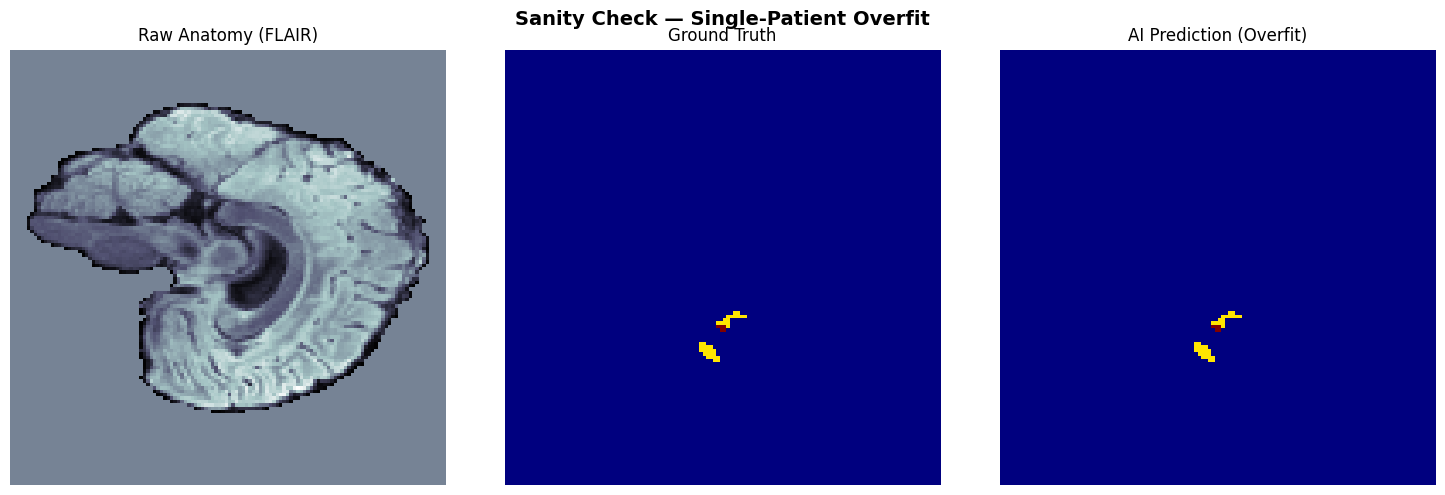

In [11]:
# visualize the overfit result
model.eval()
with torch.no_grad():
    overfit_preds = torch.argmax(model(inputs), dim=1).cpu()[0]

slice_idx = 32

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(inputs.cpu()[0, 0, slice_idx], cmap="bone")
axes[0].set_title("raw Anatomy (FLAIR)")

axes[1].imshow(labels.cpu()[0, 0, slice_idx], cmap="jet")
axes[1].set_title("ground Truth")

axes[2].imshow(overfit_preds[slice_idx], cmap="jet")
axes[2].set_title("AI prediction (Overfit)")

for ax in axes:
    ax.axis("off")

plt.suptitle("single patient overfit", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 · Full Training Loop

Now we reset the model and train properly on the full training set.

In [12]:
# -- Reset weights so the model doesn't "remember" the overfit --
model.apply(lambda m: m.reset_parameters() if hasattr(m, "reset_parameters") else None)
model.to(DEVICE)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"training for <{NUM_EPOCHS}> epochs on <{len(train_ds)}> patients")
print(f"learning rate: {LEARNING_RATE} → 1e-6 (cosine annealing)")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    steps = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for batch_scans, batch_masks in pbar:
        batch_scans = batch_scans.to(DEVICE)
        batch_masks = batch_masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_scans)
        loss = loss_fn(outputs, batch_masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        steps += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    avg_loss = epoch_loss / max(steps, 1)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f"  Epoch {epoch+1:>3d}/{NUM_EPOCHS}  Avg Loss: {avg_loss:.4f}  LR: {lr_now:.2e}")

print("-" * 60)
print("training done")

Training for 200 epochs on 100 patients...
Learning rate: 0.001 → 1e-6 (cosine annealing)
------------------------------------------------------------


Epoch 1/200:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/200  Avg Loss: 1.4550  LR: 1.00e-03


Epoch 2/200:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 3/200:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 197/200:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 198/200:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 199/200:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 200/200:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 200/200  Avg Loss: 0.1977  LR: 1.00e-06
------------------------------------------------------------
✓ Training complete.


## 5 · Comprehensive Evaluation

Time to put the model through its paces on patients it has **never seen**.
We'll evaluate from three angles:

1. **Multi-patient comparison** — side-by-side predictions for every validation patient
2. **Overlay visualization** — tumor contours drawn directly on the MRI
3. **3D tumor rendering** — a rotatable 3D surface of the predicted tumor volume
4. **Quantitative metrics** — per-patient Dice scores

In [21]:
# evaluation helpers

def find_tumor_slice(volume, axis=0):
    """Find the slice along `axis` that contains the most tumor voxels.
    Falls back to the center slice if the volume is all zeros."""
    sums = volume.sum(axis=tuple(i for i in range(volume.ndim) if i != axis))
    best = int(sums.argmax())
    if sums[best] == 0:
        best = volume.shape[axis] // 2
    return best


def create_overlay(mri_slice, mask_slice, pred_slice=None, alpha=0.4):
    """Create an RGB overlay: MRI in grayscale, ground-truth outlined in green,
    prediction outlined in red."""
    # normalize MRI to [0, 1]
    mri_norm = mri_slice.copy().astype(float)
    lo, hi = np.percentile(mri_norm[mri_norm > 0], [1, 99]) if mri_norm.any() else (0, 1)
    mri_norm = np.clip((mri_norm - lo) / max(hi - lo, 1e-8), 0, 1)

    # build RGB base from grayscale
    rgb = np.stack([mri_norm] * 3, axis=-1)

    # ground truth overlay in green
    if mask_slice is not None:
        gt_mask = (mask_slice > 0).astype(float)
        if gt_mask.any():
            edges_gt = cv2.Canny((gt_mask * 255).astype(np.uint8), 50, 150)
            # Solid fill + bright edges
            rgb[gt_mask > 0, 1] = np.clip(rgb[gt_mask > 0, 1] + alpha * 0.5, 0, 1)
            rgb[edges_gt > 0] = [0, 1, 0]

    # prediction overlay in red
    if pred_slice is not None:
        pred_mask = (pred_slice > 0).astype(float)
        if pred_mask.any():
            edges_pred = cv2.Canny((pred_mask * 255).astype(np.uint8), 50, 150)
            rgb[pred_mask > 0, 0] = np.clip(rgb[pred_mask > 0, 0] + alpha * 0.5, 0, 1)
            rgb[edges_pred > 0] = [1, 0, 0]

    return np.clip(rgb, 0, 1)


def compute_dice(pred, target, num_classes=3):
    """Compute per-class Dice coefficient (ignoring background class 0)."""
    scores = []
    for c in range(1, num_classes):
        p = (pred == c).float()
        t = (target == c).float()
        intersection = (p * t).sum()
        union = p.sum() + t.sum()
        dice = (2.0 * intersection / (union + 1e-8)).item()
        scores.append(dice)
    return scores


print("evaluation helpers loaded")

Evaluation helpers loaded.


In [14]:
# -- Run inference on ALL validation patients --
model.eval()
val_results = []

with torch.no_grad():
    for val_scan, val_mask in val_loader:
        val_scan_gpu = val_scan.to(DEVICE)
        output = model(val_scan_gpu)
        pred = torch.argmax(output, dim=1).cpu()[0]  # [D, H, W]

        val_results.append({
            "scan": val_scan[0].numpy(),      # [4, D, H, W]
            "mask": val_mask[0, 0].numpy(),    # [D, H, W]
            "pred": pred.numpy(),              # [D, H, W]
        })

print(f"inference complete on {len(val_results)} validation patients")

Inference complete on 10 validation patients.


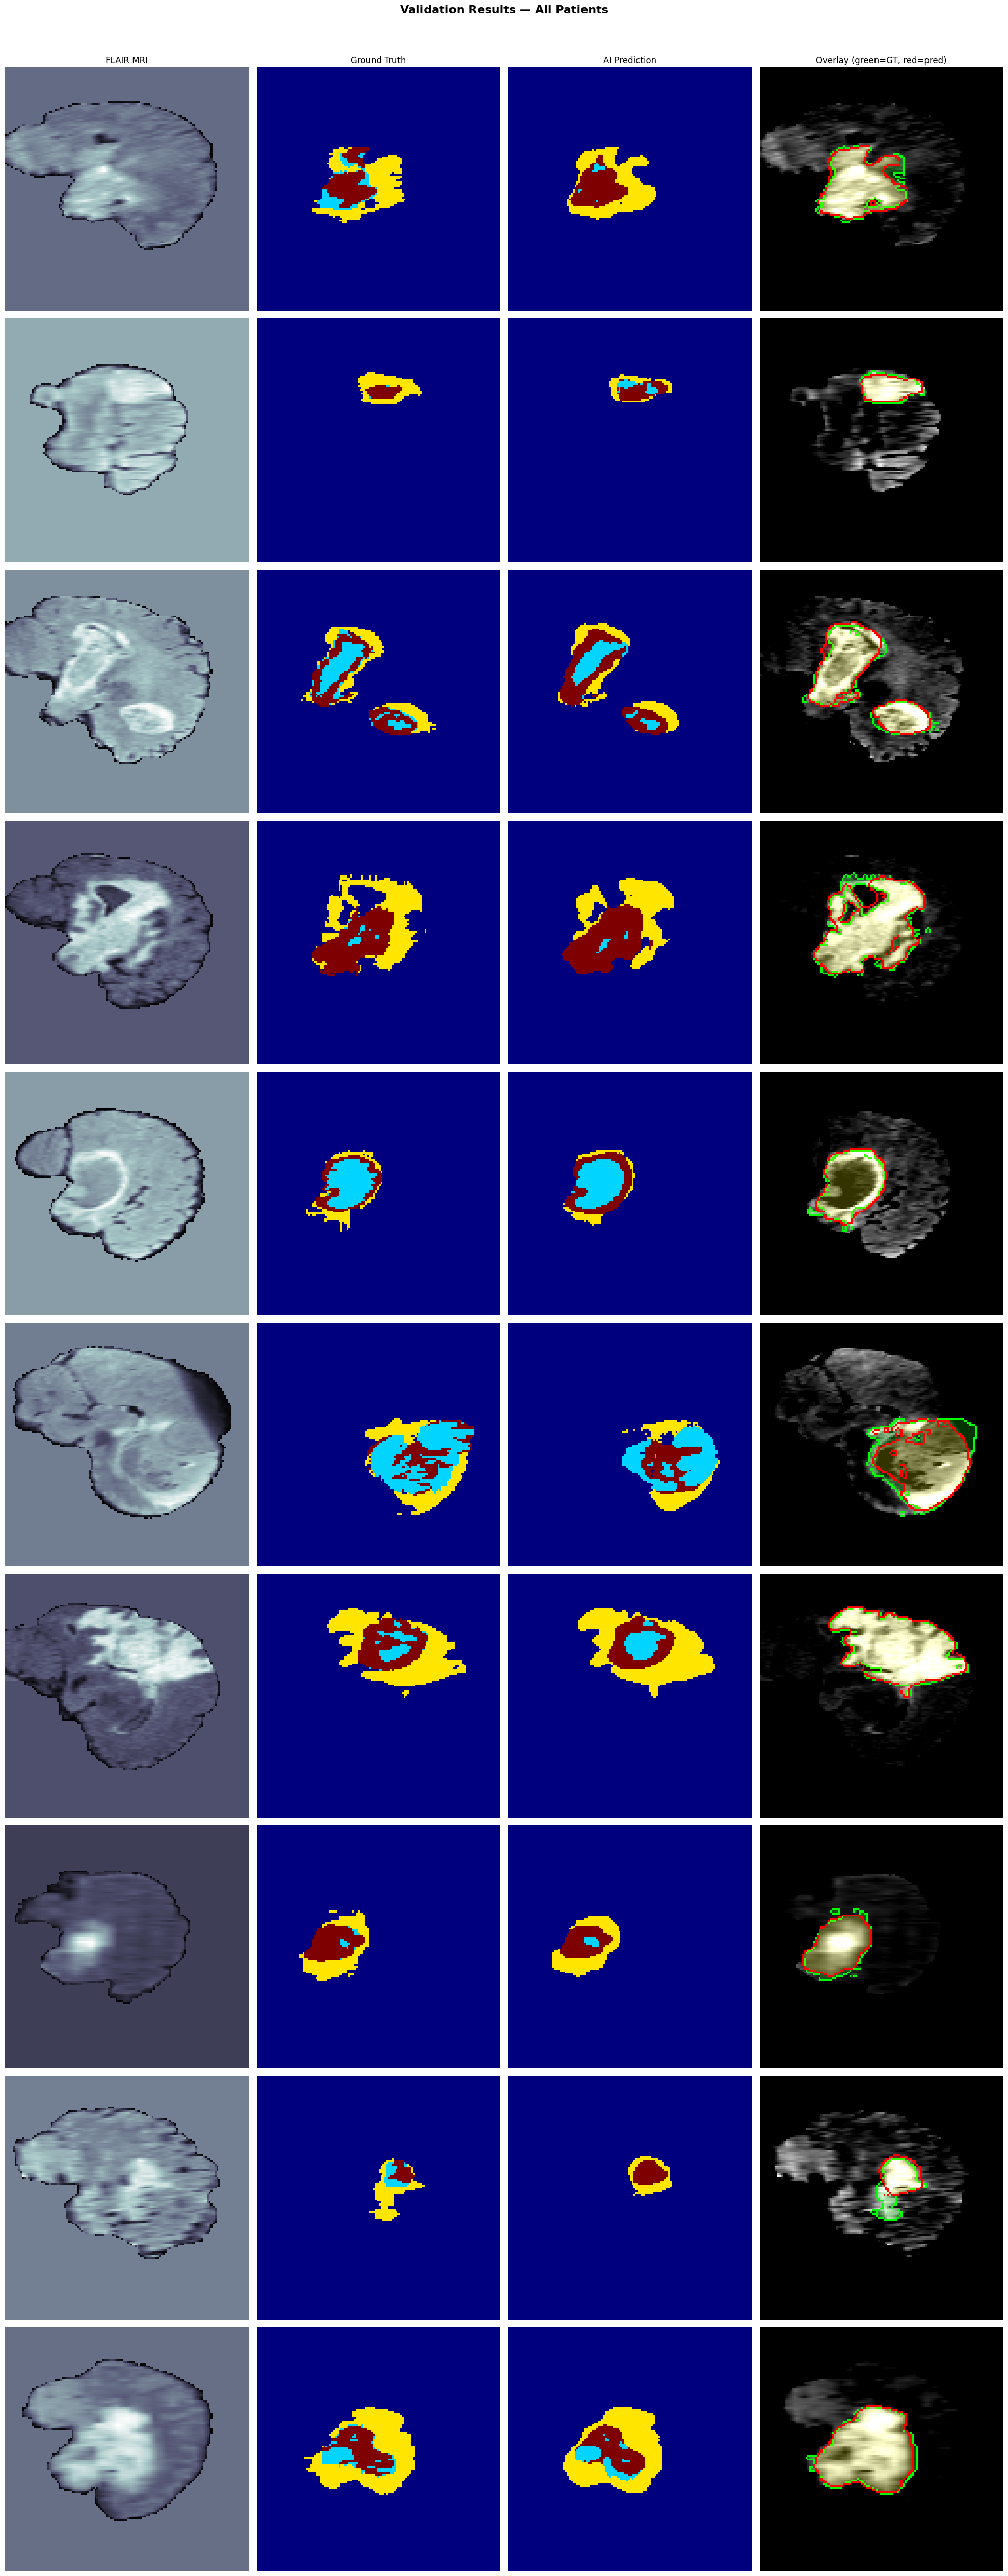

In [15]:
# comparison grid (different patients)
# FLAIR scan | Ground Truth | Prediction | Overlay


n_patients = len(val_results)
fig, axes = plt.subplots(n_patients, 4, figsize=(20, 5 * n_patients))

if n_patients == 1:
    axes = axes[np.newaxis, :]  

for i, res in enumerate(val_results):
    flair = res["scan"][0]   # FLAIR channel
    gt = res["mask"]
    pred = res["pred"]

    # pick the most interesting slice (where tumor is biggest)
    best_slice = find_tumor_slice(gt)
    if gt[best_slice].sum() == 0:
        best_slice = find_tumor_slice(pred)

    s = best_slice
    flair_s = flair[s]
    gt_s = gt[s]
    pred_s = pred[s]

    # col 1 -> FLAIR MRI
    axes[i, 0].imshow(flair_s, cmap="bone")
    axes[i, 0].set_title("FLAIR MRI" if i == 0 else "")
    axes[i, 0].set_ylabel(f"Patient {i+1}\n(slice {s})", fontsize=12, fontweight="bold")

    # col 2 -> ground truth
    axes[i, 1].imshow(gt_s, cmap="jet", vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 1].set_title("Ground Truth" if i == 0 else "")

    # col 3 -> AI prediction
    axes[i, 2].imshow(pred_s, cmap="jet", vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title("AI Prediction" if i == 0 else "")

    # col 4 -> overlay (green = truth, red = prediction)
    overlay = create_overlay(flair_s, gt_s, pred_s)
    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title("Overlay (green=GT, red=pred)" if i == 0 else "")

    for j in range(4):
        axes[i, j].axis("off")

plt.suptitle("validation results", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

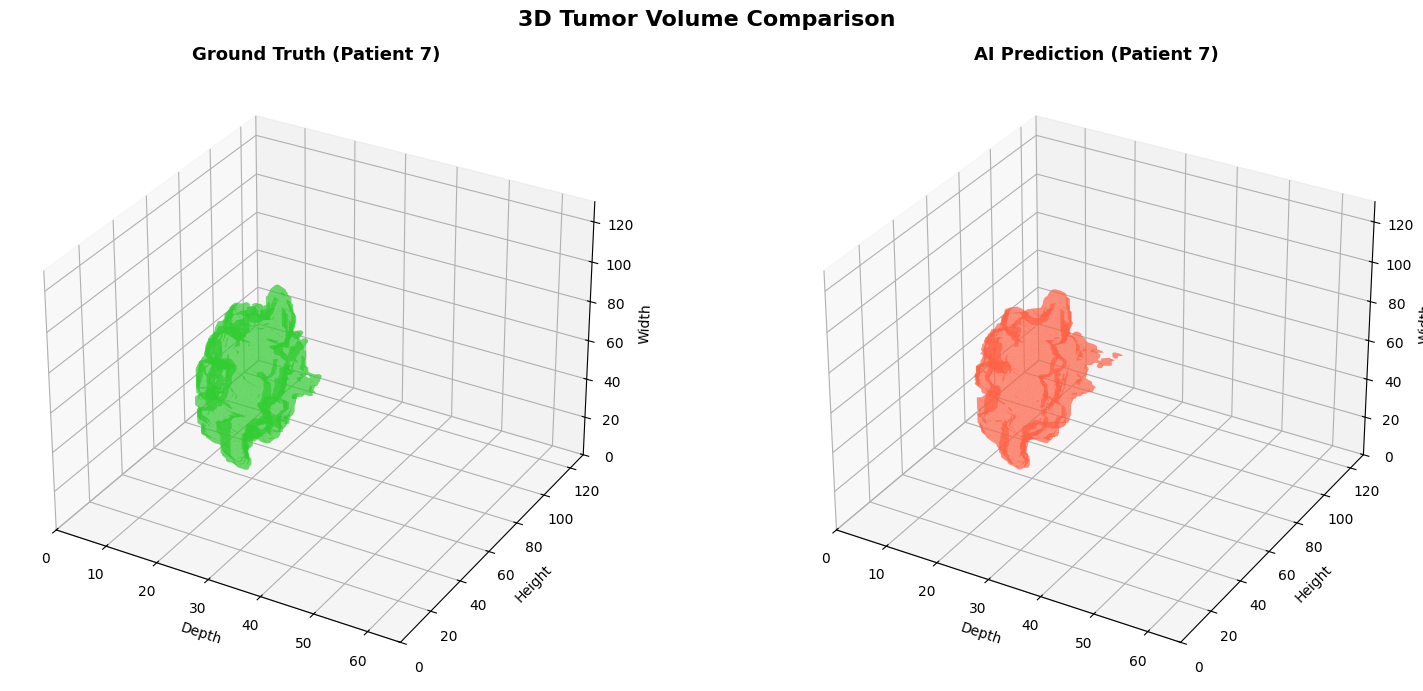

In [16]:
# 3D tumor surface rendering
# uses marching cubes to extract a 3D mesh of the tumor volume,
# then renders it alongside the ground truth for visual comparison

from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def render_tumor_3d(volume, color, ax, title, alpha=0.5):
    """Render a binary 3D volume as a surface mesh."""
    binary = (volume > 0).astype(float)

    if binary.sum() < 10:
        ax.text(0.5, 0.5, 0.5, "No tumor\ndetected",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=14, color="gray")
        ax.set_title(title)
        return

    padded = np.pad(binary, 1, mode="constant", constant_values=0)
    verts, faces, _, _ = marching_cubes(padded, level=0.5)

    mesh = Poly3DCollection(verts[faces], alpha=alpha, edgecolor="none")
    mesh.set_facecolor(color)
    ax.add_collection3d(mesh)

    ax.set_xlim(0, padded.shape[0])
    ax.set_ylim(0, padded.shape[1])
    ax.set_zlim(0, padded.shape[2])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Depth")
    ax.set_ylabel("Height")
    ax.set_zlabel("Width")


# patient with largest tumor 
tumor_sizes = [res["mask"].sum() for res in val_results]
best_patient_idx = int(np.argmax(tumor_sizes))
# if all patients have 0 tumor, just use patient 0
if tumor_sizes[best_patient_idx] == 0:
    best_patient_idx = 0

res_3d = val_results[best_patient_idx]

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection="3d")
render_tumor_3d(res_3d["mask"], color="limegreen", ax=ax1,
                title=f"Ground Truth (Patient {best_patient_idx + 1})")

ax2 = fig.add_subplot(122, projection="3d")
render_tumor_3d(res_3d["pred"], color="tomato", ax=ax2,
                title=f"AI Prediction (Patient {best_patient_idx + 1})")

plt.suptitle("3D Tumor Volume Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

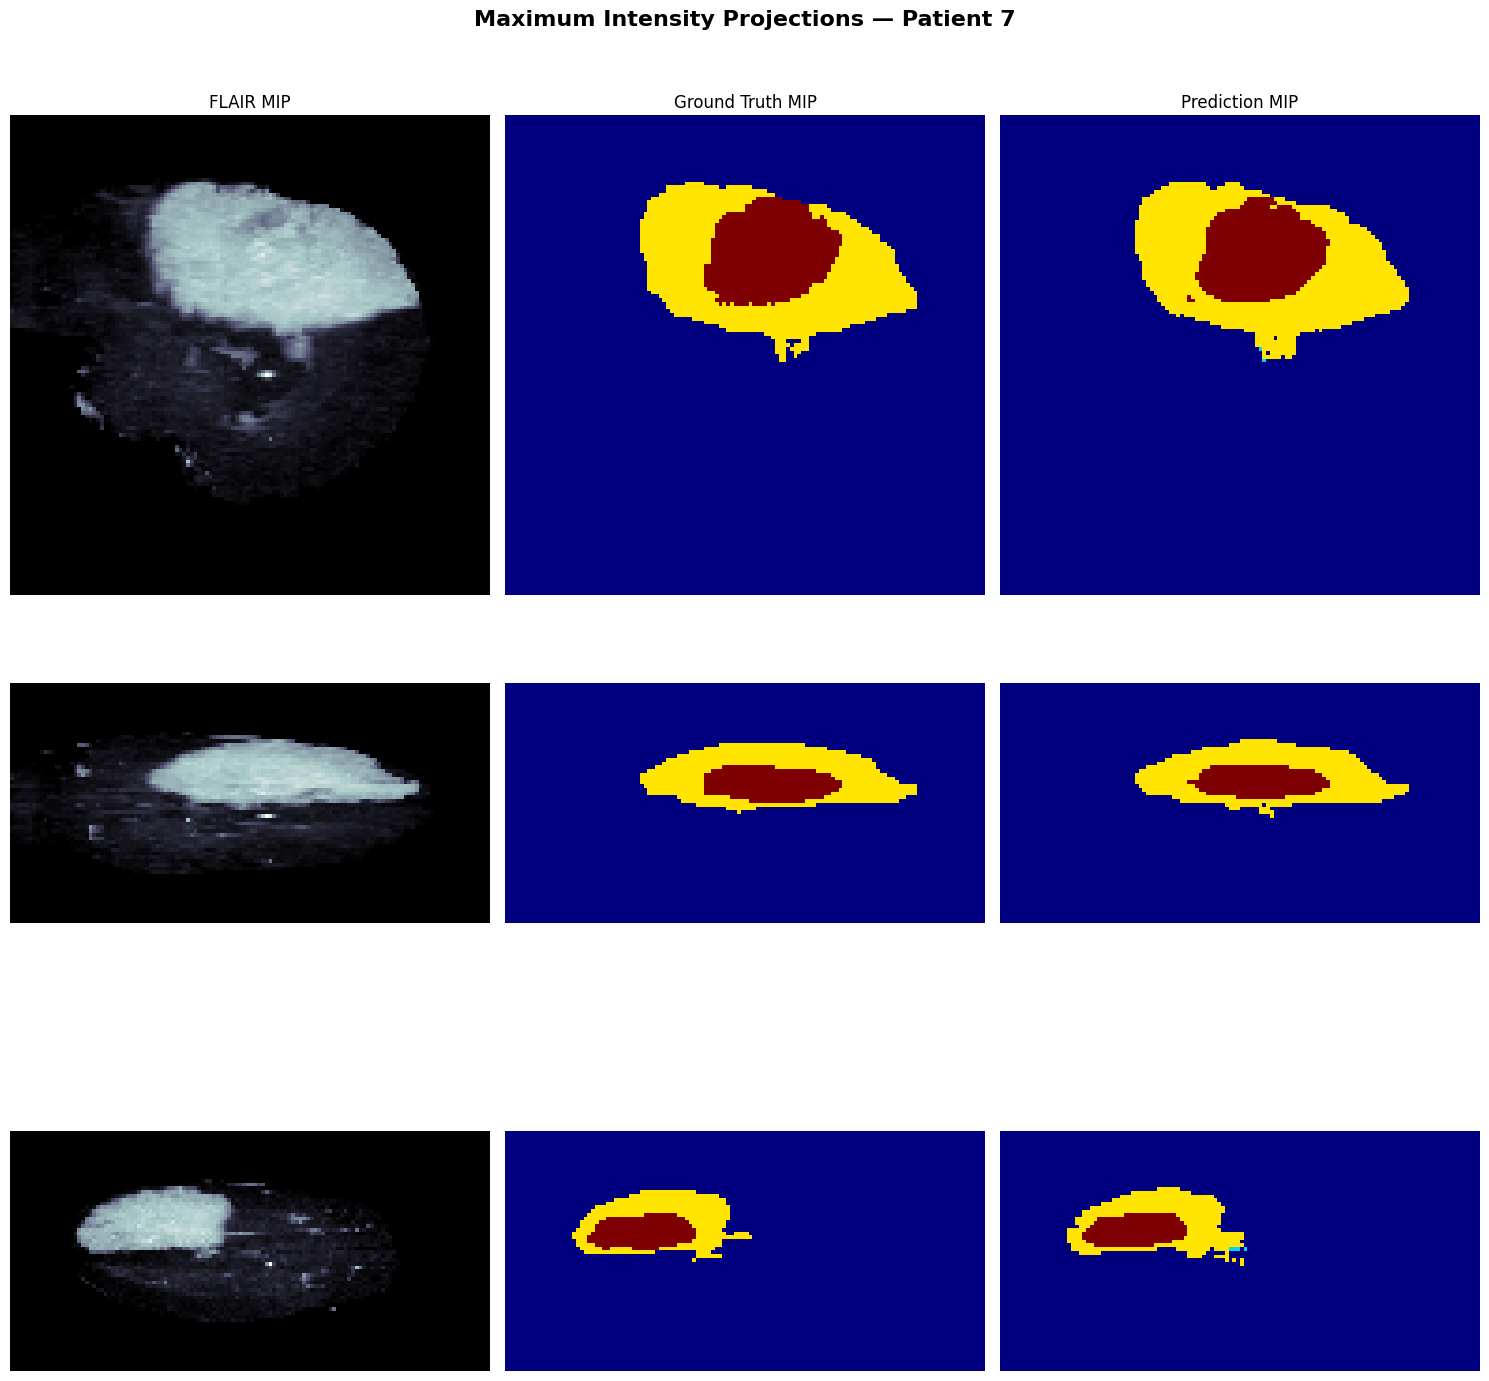

In [17]:
# maximum intensity projections (MIP)
# shows the full extent of the tumor, not just one slice

res_mip = val_results[best_patient_idx]
flair_vol = res_mip["scan"][0]
gt_vol = res_mip["mask"]
pred_vol = res_mip["pred"]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
views = [
    ("Axial (top-down)", 0),
    ("Coronal (front)", 1),
    ("Sagittal (side)", 2),
]

for row, (view_name, axis) in enumerate(views):
    mip_flair = np.max(flair_vol, axis=axis)
    mip_gt = np.max(gt_vol, axis=axis)
    mip_pred = np.max(pred_vol, axis=axis)

    axes[row, 0].imshow(mip_flair, cmap="bone")
    axes[row, 0].set_title(f"FLAIR MIP" if row == 0 else "")
    axes[row, 0].set_ylabel(view_name, fontsize=12, fontweight="bold")

    axes[row, 1].imshow(mip_gt, cmap="jet", vmin=0, vmax=NUM_CLASSES - 1)
    axes[row, 1].set_title("Ground Truth MIP" if row == 0 else "")

    axes[row, 2].imshow(mip_pred, cmap="jet", vmin=0, vmax=NUM_CLASSES - 1)
    axes[row, 2].set_title("Prediction MIP" if row == 0 else "")

    for j in range(3):
        axes[row, j].axis("off")

plt.suptitle(f"Maximum Intensity Projections — Patient {best_patient_idx + 1}",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# per-patient Dice Scores 
# dice = 2|P ∩ G| / (|P| + |G|)  →  1.0 = perfect, 0.0 = no overlap

print("Per-Patient Dice Scores")
print("=" * 50)
print(f"{'Patient':<10} {'Class 1 (Core)':<18} {'Class 2 (Edema)':<18}")
print("-" * 50)

all_dice = []
for i, res in enumerate(val_results):
    pred_t = torch.tensor(res["pred"])
    mask_t = torch.tensor(res["mask"])
    dice = compute_dice(pred_t, mask_t, NUM_CLASSES)
    all_dice.append(dice)
    print(f"  {i+1:<8} {dice[0]:<18.4f} {dice[1]:<18.4f}")

avg_dice = np.mean(all_dice, axis=0)
print("-" * 50)
print(f"  {'Avg':<8} {avg_dice[0]:<18.4f} {avg_dice[1]:<18.4f}")
print()
print(f"Mean Dice (all classes): {np.mean(avg_dice):.4f}")

Per-Patient Dice Scores
Patient    Class 1 (Core)     Class 2 (Edema)   
--------------------------------------------------
  1        0.1406             0.7542            
  2        0.0000             0.4968            
  3        0.6016             0.5850            
  4        0.8256             0.6071            
  5        0.8526             0.4497            
  6        0.5427             0.5899            
  7        0.5735             0.8612            
  8        0.1133             0.6574            
  9        0.0000             0.5489            
  10       0.4292             0.8438            
--------------------------------------------------
  Avg      0.4079             0.6394            

Mean Dice (all classes): 0.5706


## 6 · Save Model Weights

In [19]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)

Model saved to /kaggle/working/brats_3d_unet.pth
Download it from the Kaggle output panel on the right. →
